### Exploratory Data Analysis - Aviation Accidents

This notebook contains comprehensive EDA to understand patterns and trends in aviation accidents using the `CleanedAviationData.csv` file.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load preprocessed data
df = pd.read_csv('CleanedAviationData.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (88882, 22)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,...,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Year,Month,Total.Injuries
0,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,Non-Fatal,Substantial,Cessna,140,...,Personal,0.0,0.0,0.0,2.0,VMC,Takeoff,1982,January,0.0
1,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,Non-Fatal,Substantial,Cessna,401B,...,Business,0.0,0.0,0.0,2.0,IMC,Landing,1982,January,0.0
2,20020909X01560,Accident,MIA82DA029,1982-01-01,"JACKSONVILLE, FL",United States,Non-Fatal,Substantial,North American,NAVION L-17B,...,Personal,0.0,0.0,3.0,0.0,IMC,Cruise,1982,January,3.0
3,20020909X01559,Accident,FTW82DA034,1982-01-01,"HOBBS, NM",United States,Non-Fatal,Substantial,Piper,PA-28-161,...,Personal,0.0,0.0,0.0,1.0,VMC,Approach,1982,January,0.0
4,20020909X01558,Accident,ATL82DKJ10,1982-01-01,"TUSKEGEE, AL",United States,Non-Fatal,Substantial,Beech,V35B,...,Personal,0.0,0.0,0.0,1.0,VMC,Landing,1982,January,0.0


## Objective 1: Historical Trends Analysis

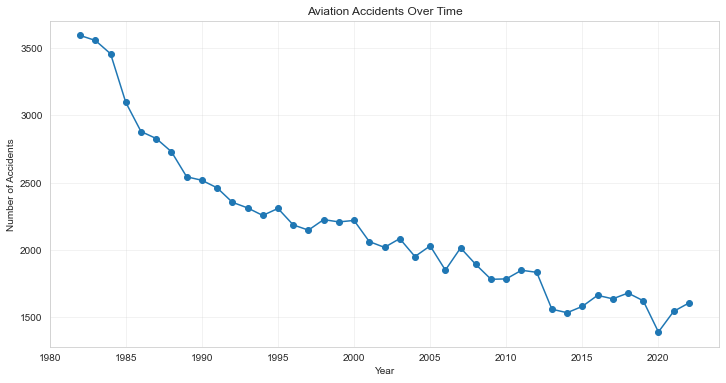

In [4]:
# Accidents per year
plt.figure(figsize=(12, 6))
yearly_accidents = df.groupby('Year').size()
yearly_accidents.plot(kind='line', marker='o')
plt.title('Aviation Accidents Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True, alpha=0.3)
plt.show(); 

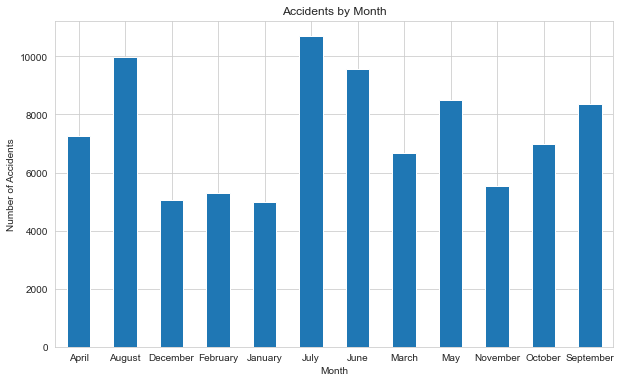

In [5]:
# Monthly patterns
plt.figure(figsize=(10, 6))
monthly_accidents = df.groupby('Month').size()
monthly_accidents.plot(kind='bar')
plt.title('Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.show(); 

## Objective 2: Aircraft and Engine Analysis

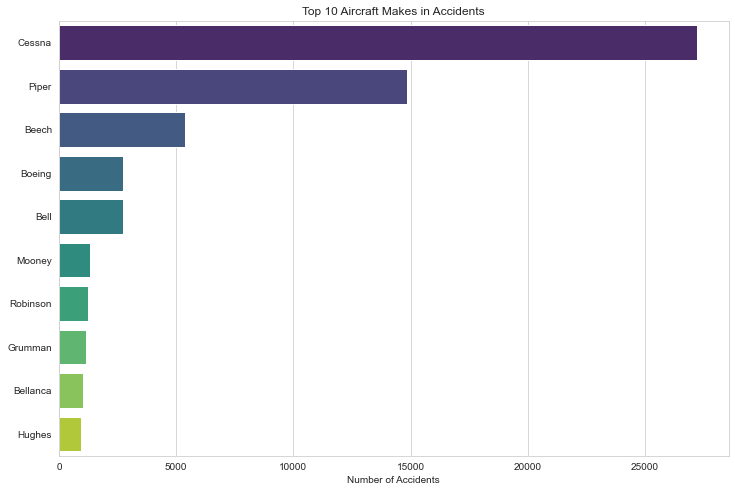

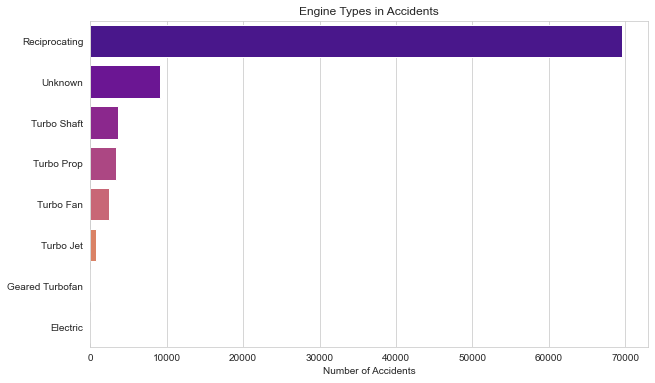

In [12]:
# Top aircraft makes
plt.figure(figsize=(12, 8))
top_makes = df['Make'].value_counts().head(10)
sns.barplot(x=top_makes.values, y=top_makes.index, palette='viridis')
plt.title('Top 10 Aircraft Makes in Accidents')
plt.xlabel('Number of Accidents')
plt.show(); 

# Engine types
plt.figure(figsize=(10, 6))
engine_counts = df['Engine.Type'].value_counts().head(8)
sns.barplot(x=engine_counts.values, y=engine_counts.index, palette='plasma')
plt.title('Engine Types in Accidents')
plt.xlabel('Number of Accidents')
plt.show(); 

## Objective 3: Weather Conditions Analysis

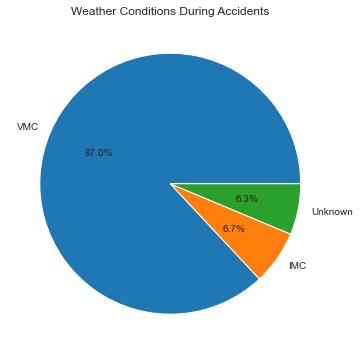

<Figure size 864x432 with 0 Axes>

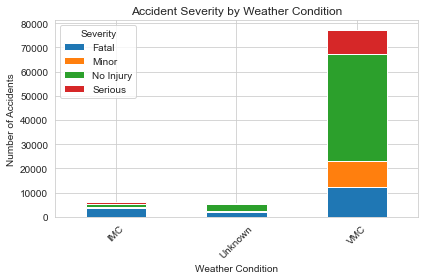

In [ ]:
# Weather conditions distribution
plt.figure(figsize=(10, 6))
weather_counts = df['Weather.Condition'].value_counts()
plt.pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%')
plt.title('Weather Conditions During Accidents')
plt.show();


<Figure size 864x432 with 0 Axes>

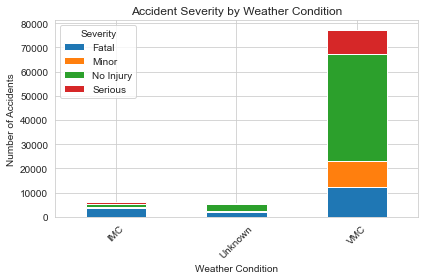

In [15]:
# Weather vs Severity
# Create Severity_Category based on injury counts
def categorize_severity(row):
    if row['Total.Fatal.Injuries'] > 0:
        return 'Fatal'
    elif row['Total.Serious.Injuries'] > 0:
        return 'Serious'
    elif row['Total.Minor.Injuries'] > 0:
        return 'Minor'
    else:
        return 'No Injury'

df['Severity_Category'] = df.apply(categorize_severity, axis=1)

plt.figure(figsize=(12, 6))
weather_severity = pd.crosstab(df['Weather.Condition'], df['Severity_Category'])
weather_severity.plot(kind='bar', stacked=True)
plt.title('Accident Severity by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.legend(title='Severity')
plt.tight_layout()
plt.show(); 

## Objective 4: Aircraft Damage Analysis

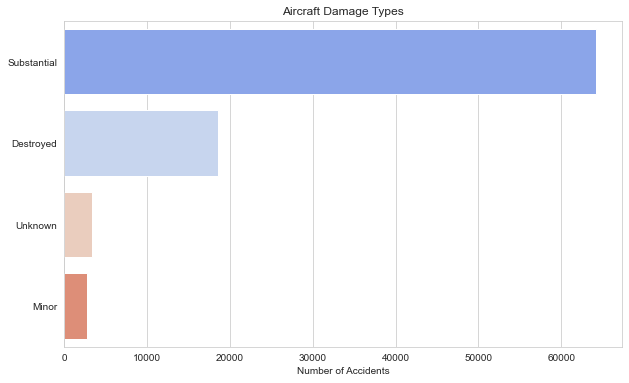

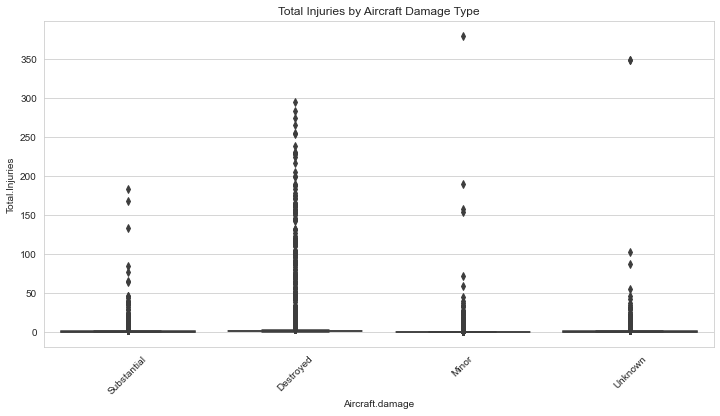

In [16]:
# Damage types distribution
plt.figure(figsize=(10, 6))
damage_counts = df['Aircraft.damage'].value_counts()
sns.barplot(x=damage_counts.values, y=damage_counts.index, palette='coolwarm')
plt.title('Aircraft Damage Types')
plt.xlabel('Number of Accidents')
plt.show(); 

# Damage vs Injuries correlation
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Aircraft.damage', y='Total.Injuries')
plt.title('Total Injuries by Aircraft Damage Type')
plt.xticks(rotation=45)
plt.show(); 

## Summary Statistics

In [17]:
# Key statistics
print("=== AVIATION ACCIDENT ANALYSIS SUMMARY ===")
print(f"Total accidents analyzed: {len(df):,}")
print(f"Date range: {df['Year'].min()} - {df['Year'].max()}")
print(f"\nTop 5 Aircraft Makes:")
print(df['Make'].value_counts().head())
print(f"\nSeverity Distribution:")
print(df['Severity_Category'].value_counts())
print(f"\nWeather Conditions:")
print(df['Weather.Condition'].value_counts())

=== AVIATION ACCIDENT ANALYSIS SUMMARY ===
Total accidents analyzed: 88,882
Date range: 1982 - 2022

Top 5 Aircraft Makes:
Cessna    27209
Piper     14869
Beech      5372
Boeing     2745
Bell       2722
Name: Make, dtype: int64

Severity Distribution:
No Injury    48398
Fatal        17807
Minor        11487
Serious      11190
Name: Severity_Category, dtype: int64

Weather Conditions:
VMC        77301
IMC         5973
Unknown     5608
Name: Weather.Condition, dtype: int64
